In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json

In [2]:
def get_json(path: str):
    """
    Load JSON file and return parsed object.
    Accepts filename or full path.
    """

    path = Path(path)

    if path.suffix != ".json":
        path = path.with_suffix(".json")

    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

In [3]:
df = pd.read_csv("../data/processed/datasets/datasetUsers5.csv")
posts_path =  "../data/raw/posts/postsFinal.json"
pdict = get_json(posts_path)

In [6]:
TEXTDICT = "../data/processed/text_features.json"
text_dict = get_json(TEXTDICT)

In [10]:
for k,v in text_dict["at://did:plc:26sbo73b4mqghlnzb74bb7ra/app.bsky.feed.post/3mfzwraclhs2r"].items():
    print(k,v)

text_len 65
word_count 14
neg 0.0
neu 1.0
pos 0.0
compound 0.0
sentiment_overall 0
grammar-word-score 1.0
grammar-sentence-score 1.0
subjectivity 0.0
polarity 0.0
emo_overall 0
emo_anger 0.003987029194831848
emo_joy 0.005671617574989796
emo_fear 0.004945153370499611
emo_disgust 0.10876777768135071
emo_surprise 0.0023337160237133503
emo_sadness 0.0047761243768036366
emo_others 0.8695186376571655
hs_aggressive 0.011227115988731384
hs_hateful 0.019834667444229126
hs_targeted 0.010089662857353687
hs_count 0
irony 1
offensive 0.17678003013134003
emoji 2
Kincaid 5.041428571428572
ARI 3.0642857142857167
Coleman-Liau 3.9252654285714286
FleschReadingEase 83.85357142857144
GunningFogIndex 8.457142857142857
LIX 35.42857142857143
SMOGIndex 8.477225575051662
RIX 3.0
DaleChallIndex 2.9501142857142857
complex_words 1.0
complex_words_dc 2.0
arts_&_culture 0.011225258931517601
business_&_entrepreneurs 0.004843094851821661
celebrity_&_pop_culture 0.0258044321089983
diaries_&_daily_life 0.127693176269531

In [21]:
import csv
from langdetect import detect, LangDetectException

def build_text_csv_trump(posts: dict, output_file="test.csv"):
    """
    Write {post_uri, text} to a CSV file
    ONLY for posts where hashtag == 'Trump'
    and the text is detected as English.
    Also prints the number of posts written.
    """
    seen = set()
    count = 0

    with open(output_file, "w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["post_uri", "full_text"])

        for uri, post in posts.items():
            if post.get("hashtag") != "Trump":
                continue

            text = post.get("record", {}).get("text")
            if not (uri and text and uri not in seen):
                continue

            try:
                if detect(str(text)) != "en":
                    continue
            except LangDetectException:
                continue

            writer.writerow([uri, str(text)])
            seen.add(uri)
            count += 1

    print(f"Number of posts written: {count}")

build_text_csv_trump(pdict)

Number of posts written: 8915


In [36]:
import pandas as pd


def enforce_exact_label_ratio_from_csv(
    neg_per_pos: int,
    csv_path: str = "../data/processed/datasets/dataset.csv",
    hashtag_col: str = "hashtag",
    label_col: str = "label",
    save_path: str = "../data/processed/datasets/dataset.csv",
    random_state: int = 42,
) -> pd.DataFrame:
    """
    For each hashtag, enforce the exact ratio:
        positives : negatives = 1 : neg_per_pos

    This is done by randomly removing either negatives or positives.

    Example:
        neg_per_pos=1 -> 1:1
        neg_per_pos=5 -> 1:5
    """
    df = pd.read_csv(csv_path)

    kept_parts = []

    for _, group in df.groupby(hashtag_col, sort=False):
        positives = group[group[label_col] == 1]
        negatives = group[group[label_col] == 0]

        n_pos = len(positives)
        n_neg = len(negatives)

        if n_pos == 0 or n_neg == 0:
            continue

        # Largest feasible exact ratio subset
        keep_pos = min(n_pos, n_neg // neg_per_pos)
        keep_neg = keep_pos * neg_per_pos

        if keep_pos == 0 or keep_neg == 0:
            continue

        positives = positives.sample(n=keep_pos, random_state=random_state)
        negatives = negatives.sample(n=keep_neg, random_state=random_state)

        balanced_group = pd.concat([positives, negatives]).sort_index()
        kept_parts.append(balanced_group)

    if not kept_parts:
        result = pd.DataFrame(columns=df.columns)
    else:
        result = pd.concat(kept_parts).sort_index().reset_index(drop=True)

    result.to_csv(save_path, index=False)
    return result
enforce_exact_label_ratio_from_csv(neg_per_pos=5)

,A_id,S_id,P_id,hashtag,label,M-P_text_len,M-P_word_count,M-P_neg,M-P_neu,M-P_pos,...,M-P_topic_count,M-P_topic_overall,M-P_single_arts_&_culture,M-P_single_business_&_entrepreneurs,M-P_single_pop_culture,M-P_single_daily_life,M-P_single_sports_&_gaming,M-P_single_science_&_technology,M-P_single_topic_count,M-P_single_topic_overall
0,did:plc:rgn3wjhjtfbtaf55ewqbjb4j,did:plc:pwo2tzlabqaxzbwrx65pzsk3,at://did:plc:pwo2tzlabqaxzbwrx65pzsk3/app.bsky...,Trump,1,189,23,0.118,0.772,0.110,...,1,12,0.235137,0.354552,0.755440,0.803142,0.242252,0.578998,3,3
1,did:plc:n7av7z5uc5cicjfp3pt3wcbv,did:plc:uspmlqltp5oof4hzt37fxhwn,at://did:plc:uspmlqltp5oof4hzt37fxhwn/app.bsky...,Trump,0,57,10,0.000,1.000,0.000,...,2,15,0.203879,0.906934,0.387862,0.411845,0.185667,0.868074,2,1
2,did:plc:wd7vicebaqdh3immo5ptnobx,did:plc:jvojjrzhq4w6quzlivkhjvog,at://did:plc:jvojjrzhq4w6quzlivkhjvog/app.bsky...,Trump,0,271,44,0.208,0.752,0.040,...,1,12,0.239726,0.264903,0.961765,0.848890,0.292512,0.251012,2,2
3,did:plc:yakt3mbalmx67hxxstbc7yfj,did:plc:nwdr7x3xh535ndo7ur7d2xki,at://did:plc:nwdr7x3xh535ndo7ur7d2xki/app.bsky...,Trump,0,287,42,0.052,0.790,0.158,...,1,12,0.279210,0.331260,0.834642,0.753679,0.401655,0.511282,3,2
4,did:plc:gdg3slu366jwtvopjiujpplr,did:plc:tqma3outiazw5tx4vo7yjb4d,at://did:plc:tqma3outiazw5tx4vo7yjb4d/app.bsky...,Trump,1,261,50,0.279,0.647,0.074,...,1,12,0.203997,0.329913,0.798238,0.863966,0.295745,0.511595,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137671,did:plc:zpsmxepkfrmywcht3lnjsqei,did:plc:fyp3qiwpwb3tpkyuey7jdgyb,at://did:plc:fyp3qiwpwb3tpkyuey7jdgyb/app.bsky...,AI,0,208,42,0.000,1.000,0.000,...,1,3,0.387120,0.625193,0.661513,0.970704,0.164504,0.152582,3,3
137672,did:plc:ajvtfx3xya45edywejtgnqye,did:plc:kwlf27csiuxv2jj6cq47fuqz,at://did:plc:kwlf27csiuxv2jj6cq47fuqz/app.bsky...,AI,0,59,9,0.000,1.000,0.000,...,1,0,0.706916,0.345422,0.839977,0.544075,0.187089,0.565428,4,2
137673,did:plc:ista4a5pfvvml6tgtosvvx5f,did:plc:m5dcinlrpxq6rm2uficksxp7,at://did:plc:m5dcinlrpxq6rm2uficksxp7/app.bsky...,AI,1,142,21,0.143,0.757,0.100,...,1,9,0.165686,0.317613,0.327479,0.295325,0.993614,0.252176,1,4
137674,did:plc:c4glx25q56hhqtz2zm7ab4d6,did:plc:2pw2hjrpyntqqijtnbh77stm,at://did:plc:2pw2hjrpyntqqijtnbh77stm/app.bsky...,AI,0,214,31,0.000,0.778,0.222,...,1,0,0.728594,0.439689,0.630246,0.466728,0.219786,0.688112,3,0


In [44]:
import pandas as pd


def count_label_ones(csv_path, label_col="label"):
    df = pd.read_csv(csv_path)

    if label_col not in df.columns:
        raise ValueError(f"Column '{label_col}' not found in {csv_path}")

    num_ones = (df[label_col] == 1).sum()
    num_zeroes = (df[label_col] == 0).sum()
    ratio = num_ones / len(df) if len(df) > 0 else 0.0

    return num_ones, ratio, num_zeroes

num_ones, ratio, num_zeroes = count_label_ones("../data/processed/datasets/dataset.csv")
print(num_ones, num_zeroes)
print(ratio)

27414 23197
0.5416609037561004


In [13]:
import pandas as pd
import numpy as np

def hashtag_overlap_matrix(df, hashtag_col="hashtag", user_col="A_id"):
    # Build hashtag -> set of unique users
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    pd.set_option("display.expand_frame_repr", False)
    hashtag_users = (
        df.groupby(hashtag_col)[user_col]
        .apply(lambda x: set(x.unique()))
        .to_dict()
    )
    
    hashtags = sorted(hashtag_users.keys())
    
    # Print unique recipient counts
    print("Pairwise overlap matrix (1:1)")

    # Initialize zero matrix
    n = len(hashtags)
    overlap_matrix = pd.DataFrame(
        np.zeros((n, n), dtype=int),
        index=hashtags,
        columns=hashtags
    )
    
    # Fill diagonal + upper triangle only
    for i, tag1 in enumerate(hashtags):
        users1 = hashtag_users[tag1]
        overlap_matrix.iloc[i, i] = len(users1)  # diagonal
        
        for j in range(i + 1, n):
            tag2 = hashtags[j]
            users2 = hashtag_users[tag2]
            overlap = len(users1 & users2)
            overlap_matrix.iloc[i, j] = overlap
    
    return overlap_matrix
matrix = hashtag_overlap_matrix(df)
print(matrix)

Pairwise overlap matrix (1:1)
                     AI  Anime  BlackHistoryMonth  Booksky  Gaza   ICE  Pokemon  Superbowl  TheTraitors  Trump
AI                 4441    182                235      127   301   517       36        222           20    439
Anime                 0   5365                177      111    38    60      484         84            7     34
BlackHistoryMonth     0      0               8210      375   411   843      165        527           31    591
Booksky               0      0                  0     5613   106   210       85        183           33    151
Gaza                  0      0                  0        0  4349   762       32        250           41    736
ICE                   0      0                  0        0     0  6158       49        525           31   1262
Pokemon               0      0                  0        0     0     0     9591        115           29     15
Superbowl             0      0                  0        0     0     0        0   

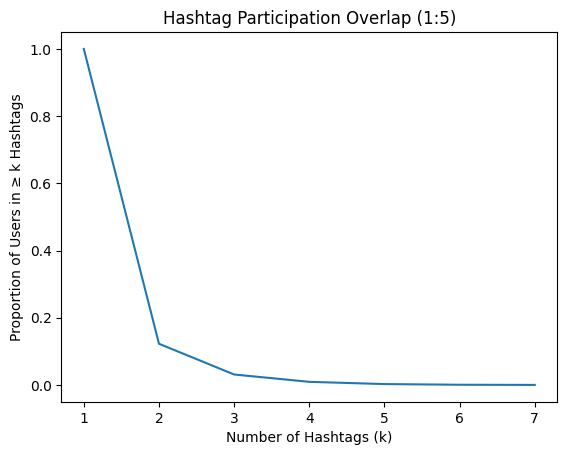

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_hashtag_participation(df, hashtag_col="hashtag", user_col="A_id"):
    
    # Count unique hashtags per user
    user_hashtag_counts = (
        df.groupby(user_col)[hashtag_col]
          .nunique()
    )
    
    total_users = len(user_hashtag_counts)
    max_k = user_hashtag_counts.max()
    
    k_values = list(range(1, max_k + 1))
    proportions = [
        (user_hashtag_counts >= k).sum() / total_users
        for k in k_values
    ]
    
    plt.figure()
    plt.plot(k_values, proportions)
    
    # 👇 Force all integer ticks to show
    plt.xticks(k_values)
    
    plt.xlabel("Number of Hashtags (k)")
    plt.ylabel("Proportion of Users in ≥ k Hashtags")
    plt.title("Hashtag Participation Overlap (1:5)")
    plt.show()


# Run
plot_hashtag_participation(df)

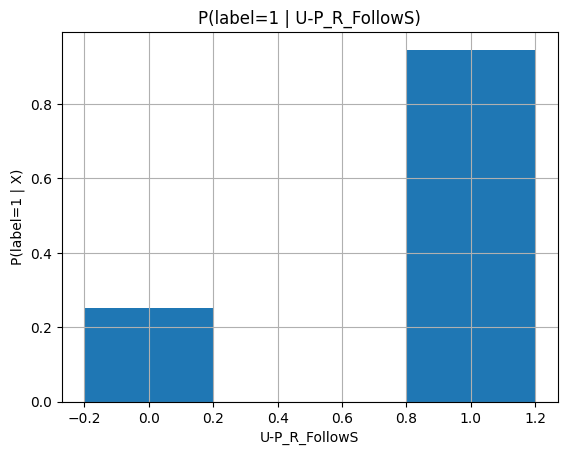

In [9]:
import numpy as np
import matplotlib.pyplot as plt


def plot_p_label_given_x(df, column, bins=50, x_max=None, title=None):
    """
    Plots P(label=1 | X).
    Handles both continuous and binary features.
    """

    x = df[column].values
    y = df["label"].values

    # Optional clipping
    if x_max is not None:
        mask = x <= x_max
        x = x[mask]
        y = y[mask]

    unique_vals = np.unique(x)

    # ------------------------------
    # Binary feature case
    # ------------------------------
    if len(unique_vals) <= 2:

        xs = []
        ps = []

        for val in sorted(unique_vals):
            mask = x == val
            if np.sum(mask) > 0:
                xs.append(val)
                ps.append(np.mean(y[mask]))

        plt.figure()
        plt.bar(xs, ps, width=0.4)

    # ------------------------------
    # Continuous feature case
    # ------------------------------
    else:

        bin_edges = np.linspace(np.min(x), np.max(x), bins + 1)
        bin_indices = np.digitize(x, bin_edges) - 1

        prob = []
        bin_centers = []

        for i in range(bins):
            mask = bin_indices == i
            if np.sum(mask) > 0:
                p = np.mean(y[mask])
                prob.append(p)
                bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)

        plt.figure()
        plt.plot(bin_centers, prob)

    plt.xlabel(column)
    plt.ylabel("P(label=1 | X)")

    if title:
        plt.title(title)
    else:
        plt.title(f"P(label=1 | {column})")

    plt.grid(True)
    plt.show()
plot_p_label_given_x(df, "U-P_R_FollowS")

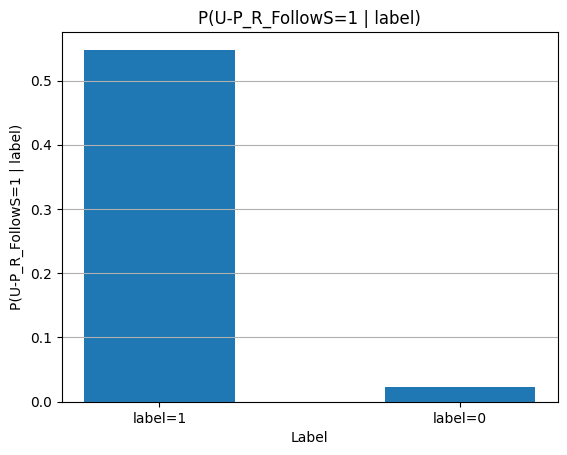

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_p_x_given_label(df, column, title=None):
    """
    Plots P(X=1 | label).
    Assumes the column is binary (0/1).
    """

    x = df[column].values
    y = df["label"].values

    p_x1_given_label1 = np.mean(x[y == 1])
    p_x1_given_label0 = np.mean(x[y == 0])

    xs = ["label=1", "label=0"]
    ps = [p_x1_given_label1, p_x1_given_label0]

    plt.figure()
    plt.bar(xs, ps, width=0.5)

    plt.ylabel(f"P({column}=1 | label )")
    plt.xlabel("Label")

    if title:
        plt.title(title)
    else:
        plt.title(f"P({column}=1 | label )")

    plt.grid(axis="y")
    plt.show()
plot_p_x_given_label(df,"U-P_R_FollowS")

In [15]:
from collections import defaultdict

def count_zero_vs_nonzero_reposts_by_hashtag(posts: dict) -> dict:
    """
    Count, for each hashtag:
      - how many posts have 0 reposts
      - how many posts have 1+ reposts

    Returns:
        {
            "hashtag1": {"zero_reposts": ..., "nonzero_reposts": ..., "total_posts": ...},
            ...
        }
    """
    counts = defaultdict(lambda: {
        "zero_reposts": 0,
        "nonzero_reposts": 0,
        "total_posts": 0,
    })

    for _, post in posts.items():
        hashtag = post.get("hashtag")
        if not hashtag:
            continue

        reposts = post.get("stored_reposters") or []

        counts[hashtag]["total_posts"] += 1

        if len(reposts) == 0:
            counts[hashtag]["zero_reposts"] += 1
        else:
            counts[hashtag]["nonzero_reposts"] += 1

    return dict(counts)
stats = count_zero_vs_nonzero_reposts_by_hashtag(pdict)

for hashtag, values in stats.items():
    print(hashtag, values)

Trump {'zero_reposts': 7640, 'nonzero_reposts': 2615, 'total_posts': 10255}
ICE {'zero_reposts': 8019, 'nonzero_reposts': 2968, 'total_posts': 10987}
AI {'zero_reposts': 8614, 'nonzero_reposts': 2386, 'total_posts': 11000}
Gaza {'zero_reposts': 7151, 'nonzero_reposts': 3822, 'total_posts': 10973}
Pokemon {'zero_reposts': 6891, 'nonzero_reposts': 4098, 'total_posts': 10989}
BlackHistoryMonth {'zero_reposts': 6158, 'nonzero_reposts': 4777, 'total_posts': 10935}
Booksky {'zero_reposts': 7171, 'nonzero_reposts': 3764, 'total_posts': 10935}
Superbowl {'zero_reposts': 9058, 'nonzero_reposts': 1901, 'total_posts': 10959}
TheTraitors {'zero_reposts': 9639, 'nonzero_reposts': 1361, 'total_posts': 11000}
Anime {'zero_reposts': 6216, 'nonzero_reposts': 4481, 'total_posts': 10697}


In [16]:
from collections import defaultdict

def count_zero_vs_nonzero_reposts_by_hashtag(posts: dict) -> dict:
    """
    Count, for each hashtag:
      - how many posts have repostCount == 0
      - how many posts have repostCount > 0

    Returns:
        {
            "hashtag1": {
                "zero_reposts": int,
                "nonzero_reposts": int,
                "total_posts": int,
            },
            ...
        }
    """
    counts = defaultdict(lambda: {
        "zero_reposts": 0,
        "nonzero_reposts": 0,
        "total_posts": 0,
    })

    for _, post in posts.items():
        hashtag = post.get("hashtag")
        if not hashtag:
            continue

        repost_count = post.get("repostCount", 0) or 0

        counts[hashtag]["total_posts"] += 1

        if repost_count == 0:
            counts[hashtag]["zero_reposts"] += 1
        else:
            counts[hashtag]["nonzero_reposts"] += 1

    return dict(counts)
stats = count_zero_vs_nonzero_reposts_by_hashtag(pdict)

for hashtag, values in stats.items():
    print(hashtag, values)

Trump {'zero_reposts': 7608, 'nonzero_reposts': 2647, 'total_posts': 10255}
ICE {'zero_reposts': 7986, 'nonzero_reposts': 3001, 'total_posts': 10987}
AI {'zero_reposts': 8553, 'nonzero_reposts': 2447, 'total_posts': 11000}
Gaza {'zero_reposts': 7071, 'nonzero_reposts': 3902, 'total_posts': 10973}
Pokemon {'zero_reposts': 6873, 'nonzero_reposts': 4116, 'total_posts': 10989}
BlackHistoryMonth {'zero_reposts': 6076, 'nonzero_reposts': 4859, 'total_posts': 10935}
Booksky {'zero_reposts': 7117, 'nonzero_reposts': 3818, 'total_posts': 10935}
Superbowl {'zero_reposts': 8219, 'nonzero_reposts': 2740, 'total_posts': 10959}
TheTraitors {'zero_reposts': 9615, 'nonzero_reposts': 1385, 'total_posts': 11000}
Anime {'zero_reposts': 6009, 'nonzero_reposts': 4688, 'total_posts': 10697}
